### Training the model for potato disease classification

In [1]:
# import modules

import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [37]:
print(tf.__version__)

2.19.0


In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "datasets",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    seed=123
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset) # each batch will have 32 samples now total images / batch_size will give len(dataset) -> total 68 batches with 32 samples in each batch

68

In [6]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch)

(32, 256, 256, 3)
tf.Tensor([1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 2 0 0], shape=(32,), dtype=int32)


2025-05-01 10:23:35.225268: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


This first batch has 32 samples each 256x256 pixels and 3 colors (RGB)

In [7]:
for image_batch, label_batch in dataset.take(1):
    # print(image_batch[0].numpy())
    print(image_batch[0].shape)

(256, 256, 3)


2025-05-01 10:23:35.263917: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


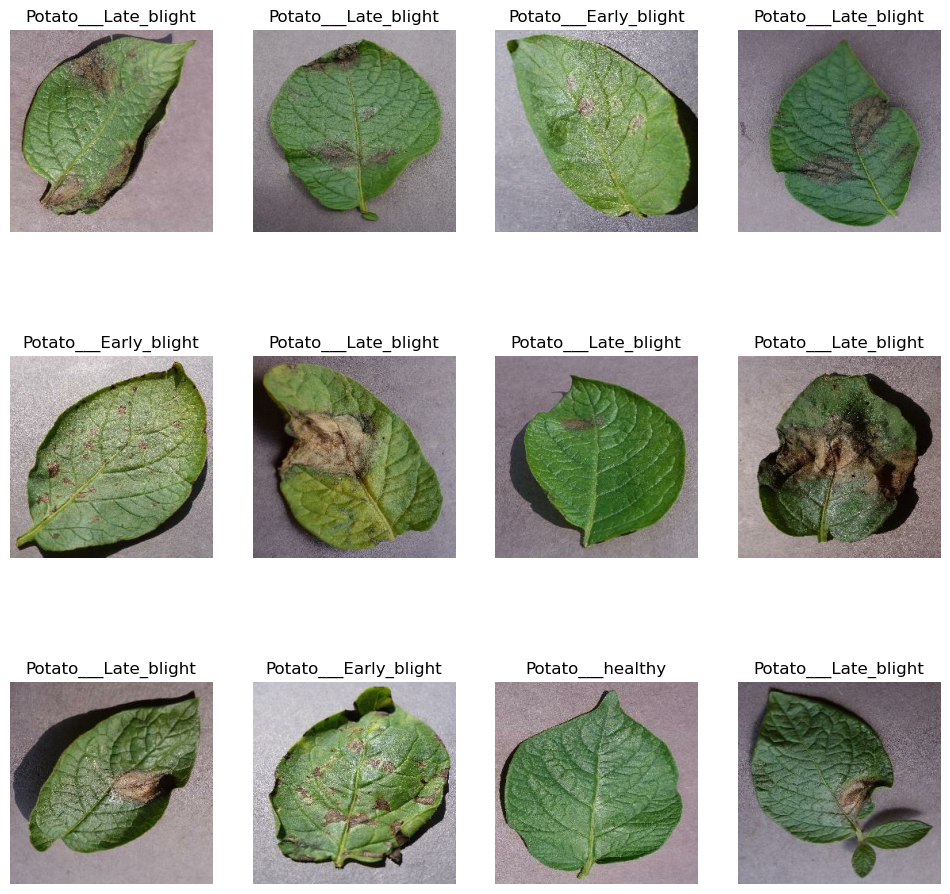

In [8]:
# display the image

plt.figure(figsize=(12, 12))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")


### Train and Test Data

In [9]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [10]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [11]:
print(len(train_ds), len(test_ds), len(val_ds))

54 8 6


### Cache, Shuffle, and Prefetch the Dataset

In [12]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

### Model Training & Building

#### Scaling, Standardization & Normalization

The image size if 256x256 pixels; first thing we need to do with an incoming image is `resize` it to 256x256 pixels which is our training size. Because a user can click a picture in any size and upload it, but we need to make sure we resize it.

Next, we need to standardize the RGB channel values which range from 0-255, generally we feed smaller values to neural network in the range 0-1 so we will standardize these values 0-1.

In [13]:
resizing_and_rescaling = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

#### Data Augmentation

In [14]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
    ]
)

#### Building a CNN Model

In [ ]:
CHANNELS = 3
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3


model = models.Sequential([
    resizing_and_rescaling,
    data_augmentation,
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [16]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [18]:
EPOCHS = 25

In [19]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4330 - loss: 0.9543 - val_accuracy: 0.6667 - val_loss: 0.8208
Epoch 2/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6175 - loss: 0.7735 - val_accuracy: 0.7344 - val_loss: 0.6023
Epoch 3/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7701 - loss: 0.5090 - val_accuracy: 0.9062 - val_loss: 0.2451
Epoch 4/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9005 - loss: 0.2488 - val_accuracy: 0.9062 - val_loss: 0.2364
Epoch 5/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9062 - loss: 0.2232 - val_accuracy: 0.8594 - val_loss: 0.4017
Epoch 6/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9393 - loss: 0.1705 - val_accuracy: 0.9219 - val_loss: 0.2126
Epoch 7/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9264 - loss: 0.1929 - val_accuracy: 0.8854 - val_loss: 0.3067
Epoch 8/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9200 - loss: 0.1893 - val_accuracy: 0.9583 - val_loss:

The total training with 25 epochs took around 32 mins on macbook m1. The accuracy is 98% in training and 94% in validation

In [20]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 388ms/step - accuracy: 0.9688 - loss: 0.0866


In [21]:
scores

[0.08486822247505188, 0.97265625]

### Plotting the training history

In [22]:
history

In [23]:
history.params

{'verbose': 1, 'epochs': 25, 'steps': 54}

In [24]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

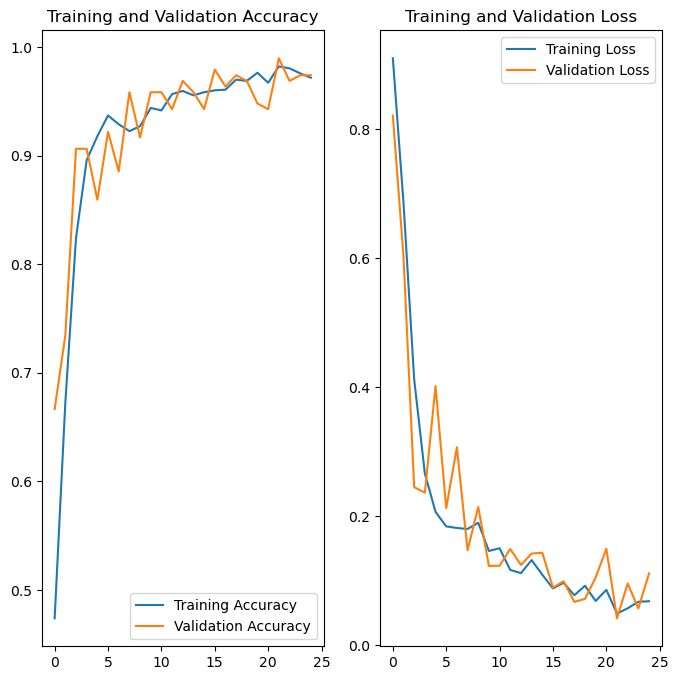

In [26]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
[9.1242093e-01 8.7578334e-02 7.2841505e-07]
predicted label: Potato___Early_blight


2025-05-01 10:53:44.553981: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


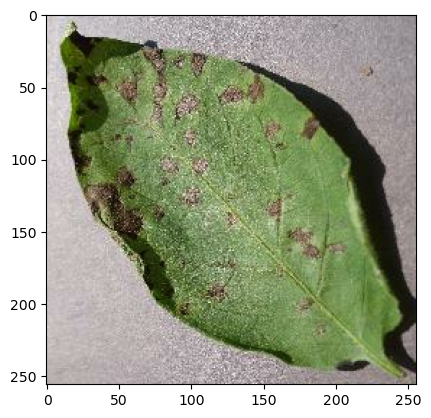

In [27]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:", class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print(batch_prediction[0])
    print("predicted label:", class_names[np.argmax(batch_prediction[0])])

In [28]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    
    print(predictions)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
[[5.30948237e-05 9.99946952e-01 1.00269015e-10]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[9.999206e-01 7.933949e-05 5.449569e-11]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[3.2628916e-06 9.9999678e-01 2.3900252e-08]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[4.5414633e-04 9.9903870e-01 5.0720293e-04]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[9.9981719e-01 1.8285502e-04 6.1855855e-12]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[9.9996746e-01 3.2502659e-05 7.6777363e-14]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[4.8592924e-10 9.9999964e-01 3.4209796e-07]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[1.5782767e-06 1.3711112e-02 9.8628730e-01]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[1.4886471e-04 9.9944097e-01 4.1018869e-04]]


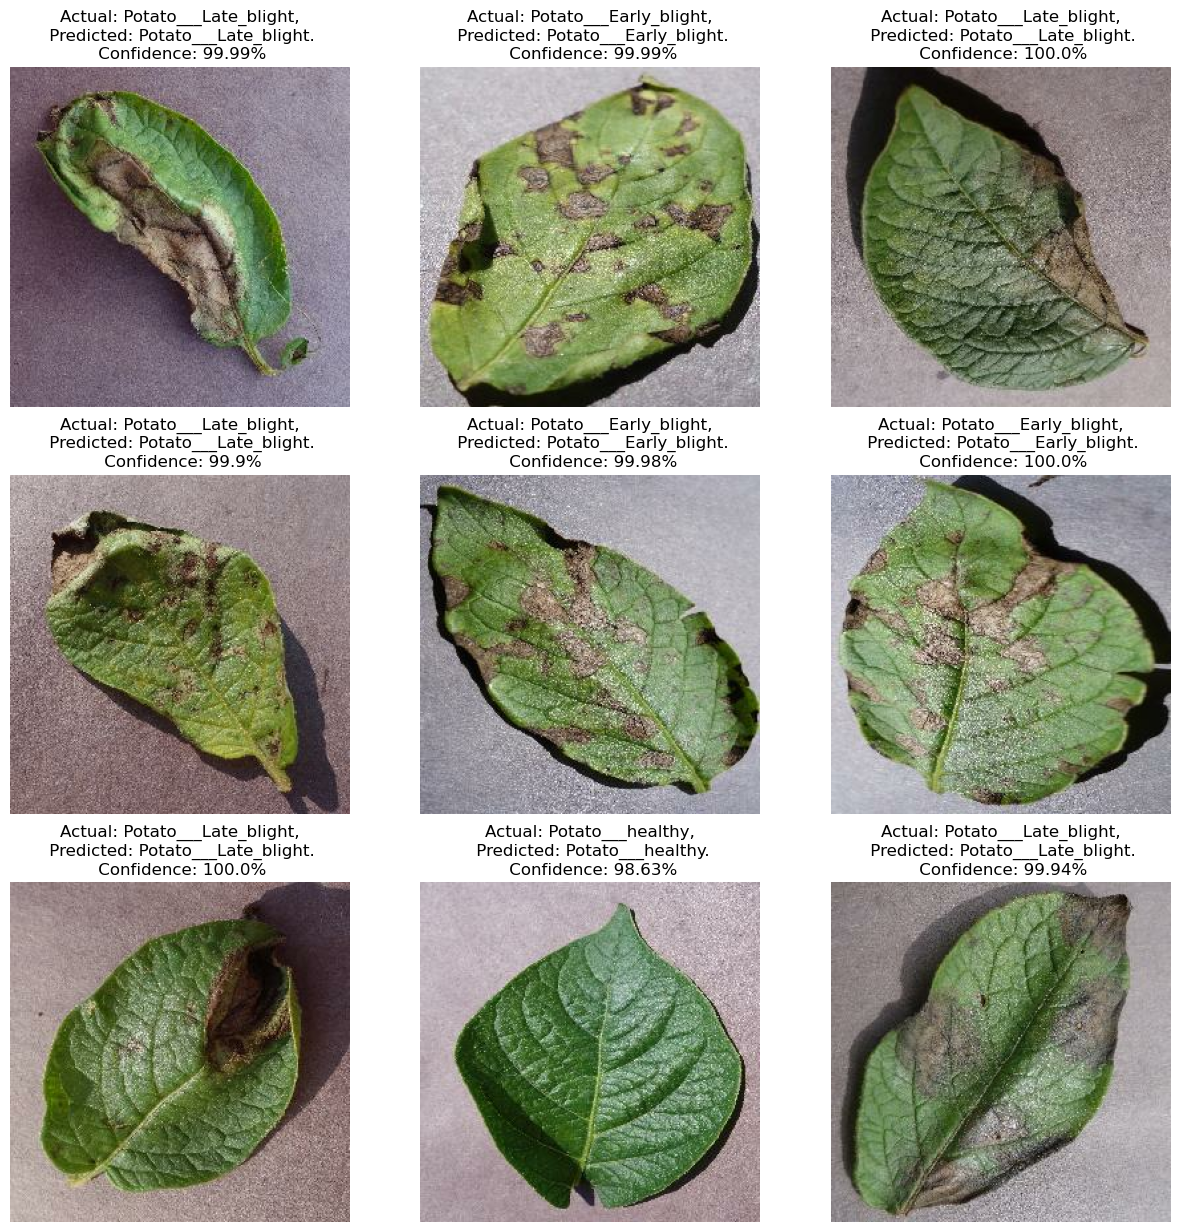

In [29]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

### Saving the TensorFlow Model

In [30]:
# model.export("../models/v1")

In [32]:
# use a keras format to save it for retraining purpose.
# prefer exporting the model for prod deployment
model.save("./models/potato_disease_detect_model.keras")

In [33]:
# load the model
loaded_model = tf.keras.models.load_model(
    "./models/potato_disease_detect_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[[9.4207017e-08 4.6494137e-02 9.5350575e-01]]


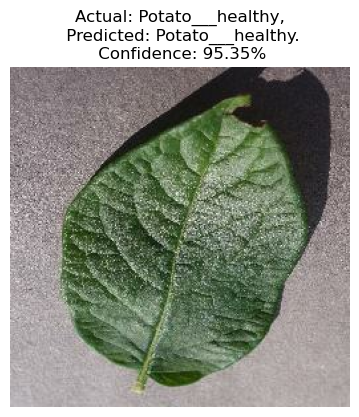

In [34]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(1):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(loaded_model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

In [39]:
model_version="v1"
model.export(f"./models/{model_version}")

INFO:tensorflow:Assets written to: ./models/v1/assets


INFO:tensorflow:Assets written to: ./models/v1/assets


Saved artifact at './models/v1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  5513314576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513315536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513317456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513318992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513316112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513317840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513320144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513319376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513319184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513321104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513320912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5513